Data loaded: (128715, 2)
        timestamp_ist   steam_flow
0 2025-12-01 05:30:01  1804.835449
1 2025-12-01 05:30:11  1783.585938
2 2025-12-01 05:30:21  1779.130493
3 2025-12-01 05:30:31  1772.275757
4 2025-12-01 05:30:41  1772.275757
Anomalies detected: 3840
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2896/2896 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - loss: 0.0037 - val_loss: 1.7001e-04
Epoch 2/25
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - loss: 1.0979e-04 - val_loss: 1.6215e-04
Epoch 3/25
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - loss: 8.1293e-05 - val_loss: 1.2174e-04
Epoch 4/25
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - loss: 7.1804e-05 - val_loss: 1.0978e-04
Epoch 5/25
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - loss: 5.9402e-05 - val_loss: 1.1151e-04
Epoch 6/25
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - loss: 6.1672e-05 - val_loss: 1.0202e-04
Epoch 7/25
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 80s 16ms/step - loss: 5.6044e-05 - val_loss: 1.0734e-04
Epoch 8/25
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 84s 16ms/step - loss: 6.8645e-05 - val_loss: 1.0563e-04
Epoch 9/25
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 48s 17ms/step - loss: 6.2649e-05 - val_loss: 1.0397e-04
Epoch 10/25
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - loss: 5.7683e-05 - val_loss: 1.2610e-04
Epoch 11/25
2896/2896 ━━━━━━━━━━━━

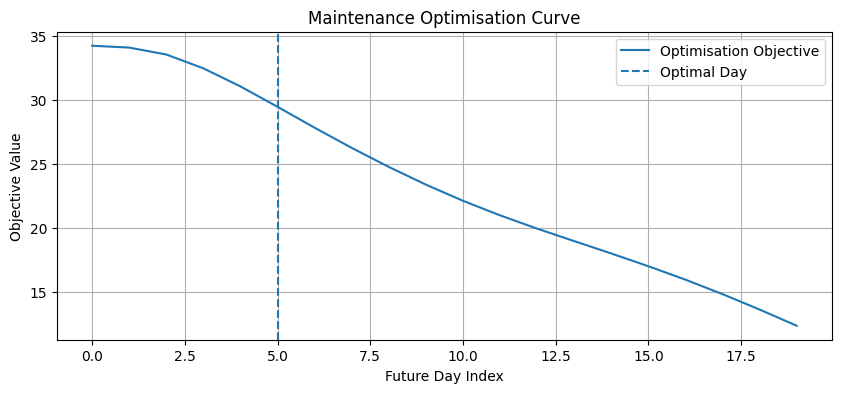

Optimal Maintenance Day: 5
Isolation Forest Metrics (CV):
Precision: 0.6018139252138657
Recall: 0.9201870278238438
F1-score: 0.6675026764184606
Regression Metrics:
MAE: 14.280504108462786
RMSE: 27.622058612384325
Results saved to steam_flow_anomaly_detection_results.csv


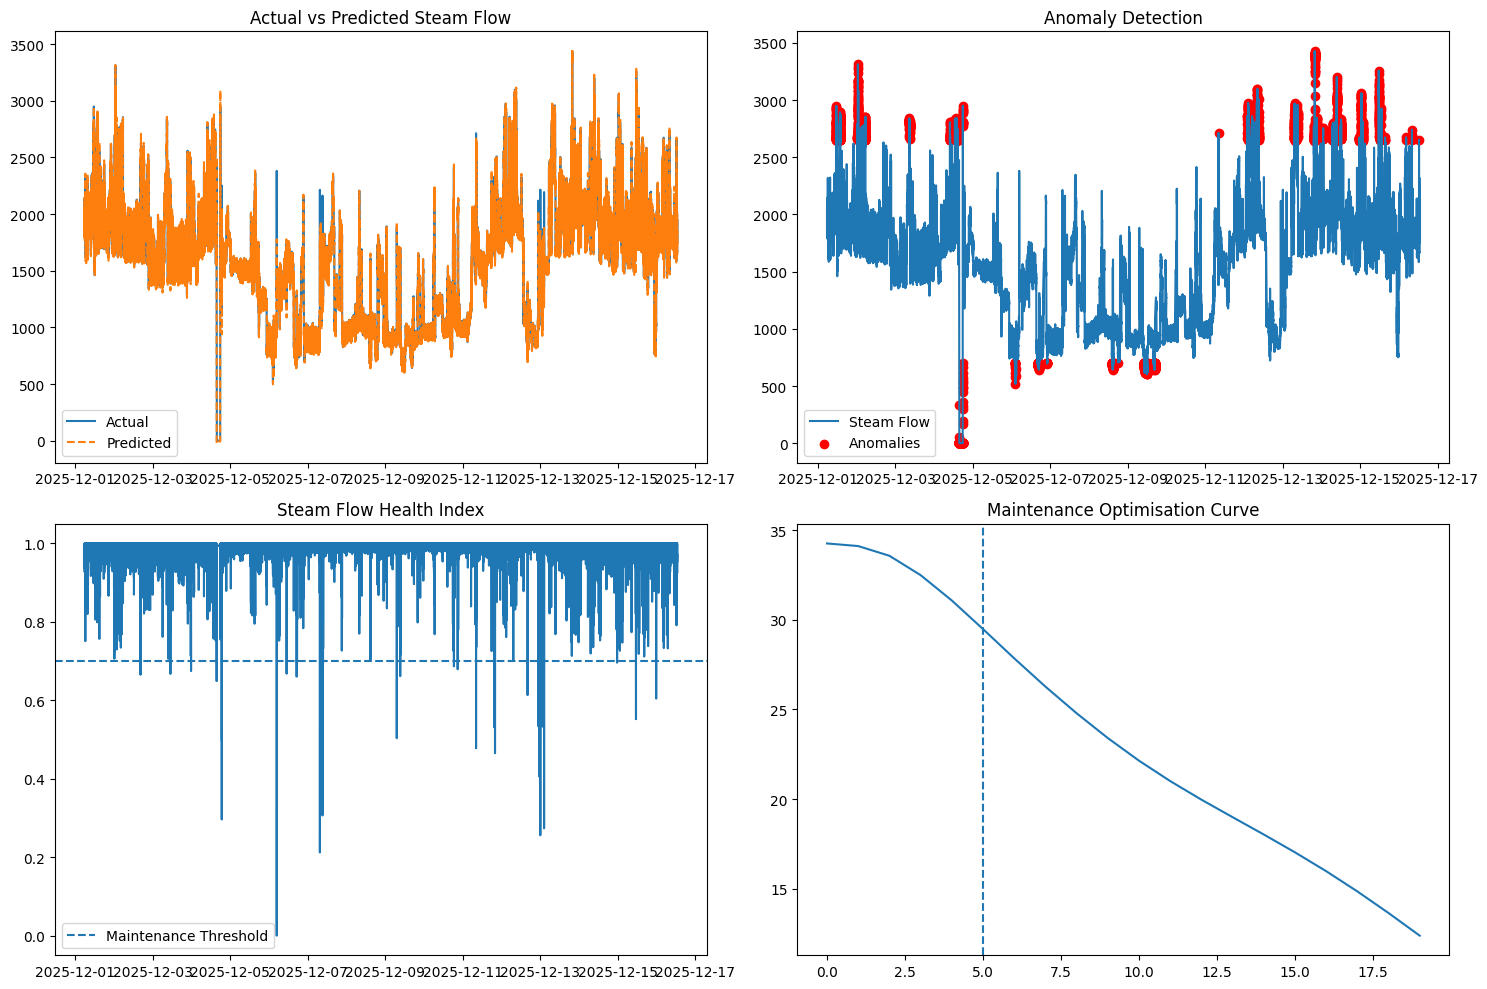

In [1]:
# -*- coding: utf-8 -*-
"""
Enhanced Steam Flow Anomaly Detection using Isolation Forest
Includes actual vs predicted, health index, maintenance optimization, and metrics (precision, recall, F1)
References and extends the existing steam_flow_analysis_in_python.py code structure.
Assumes data file: "STEAM - FLOW (PALM) (2).xlsx" with columns 'timestamp_ist' and 'value'
Compatible with Jupyter/Colab environment.
"""

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error
from scipy.optimize import minimize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# Load data (same as existing code)
file_path = "/content/STEAM - FLOW  (PALM).xlsx"  # Update path as needed
df = pd.read_excel(file_path, engine='openpyxl')
df['timestamp_ist'] = pd.to_datetime(df['timestamp_ist'])
df = df.sort_values('timestamp_ist')
df = df.rename(columns={'value': 'steam_flow'})
df = df[['timestamp_ist', 'steam_flow']].dropna()
print("Data loaded:", df.shape)
print(df.head())

# Isolation Forest for Anomaly Detection (enhanced from existing)
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
df['anomaly_flag_iso'] = iso.fit_predict(df[['steam_flow']])
df['anomaly_flag_iso'] = df['anomaly_flag_iso'].apply(lambda x: 1 if x == -1 else 0)
print("Anomalies detected:", df['anomaly_flag_iso'].sum())

# LSTM Prediction (same as existing)
scaler = MinMaxScaler()
scaled_flow = scaler.fit_transform(df[['steam_flow']])

def create_sequences(data, window=30):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

WINDOW_SIZE = 30
X, y = create_sequences(scaled_flow, WINDOW_SIZE)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential([LSTM(64, activation='relu', input_shape=(WINDOW_SIZE, 1)), Dense(1)])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.1, verbose=1)

# Actual and Predicted Values
predicted_scaled = model.predict(X)
predicted_flow = scaler.inverse_transform(predicted_scaled)
df = df.iloc[WINDOW_SIZE:].reset_index(drop=True)
df['predicted_steam_flow'] = predicted_flow.flatten()
actual = df['steam_flow'].values
predicted = df['predicted_steam_flow'].values

# Steam Flow Health Index (same as existing)
df['deviation'] = abs(df['steam_flow'] - df['predicted_steam_flow'])
max_dev = df['deviation'].max()
df['health_index'] = 1 - (df['deviation'] / max_dev)
df['maintenance_required'] = (df['health_index'] < 0.7).astype(int)

# Future Forecast for Optimization (same as existing)
future_steps = 20
last_sequence = scaled_flow[-WINDOW_SIZE:]
future_predictions = []
for _ in range(future_steps):
    pred = model.predict(last_sequence.reshape(1, WINDOW_SIZE, 1), verbose=0)
    future_predictions.append(pred[0,0])
    last_sequence = np.vstack([last_sequence[1:], pred])
future_forecast = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1)).flatten()

df_timestamp = df['timestamp_ist'].iloc[-1]
time_interval = df['timestamp_ist'].diff().median()
future_times = [df_timestamp + (i+1)*time_interval for i in range(future_steps)]
forecast_df = pd.DataFrame({'timestamp_ist': future_times, 'predicted_steam_flow': future_forecast})
forecast_horizon = len(forecast_df)
forecast_df['predicted_risk'] = abs(forecast_df['predicted_steam_flow'] - df['steam_flow'].mean()) / df['steam_flow'].std()

# Maintenance Optimization Curve (same as existing)
W_RISK, W_STEAM_LOSS, W_DELAY = 0.5, 0.3, 0.2
def optimisation_objective(x):
    day = int(x[0])
    day = max(0, min(day, forecast_horizon - 1))
    risk_penalty = forecast_df['predicted_risk'].iloc[:day+1].mean()
    steam_loss_penalty = abs(forecast_df['predicted_steam_flow'].iloc[day] - df['steam_flow'].mean())
    delay_penalty = day / forecast_horizon
    return W_RISK * risk_penalty + W_STEAM_LOSS * steam_loss_penalty + W_DELAY * delay_penalty

result = minimize(optimisation_objective, x0=[5], bounds=[(0, forecast_horizon - 1)], method='L-BFGS-B')
optimal_day = int(result.x[0])

# Plot Maintenance Optimisation Curve
days = np.arange(forecast_horizon)
costs = [optimisation_objective([d]) for d in days]
plt.figure(figsize=(10,4))
plt.plot(days, costs, label='Optimisation Objective')
plt.axvline(optimal_day, linestyle='--', label='Optimal Day')
plt.xlabel('Future Day Index')
plt.ylabel('Objective Value')
plt.title('Maintenance Optimisation Curve')
plt.legend()
plt.grid(True)
plt.savefig('maintenance_optimisation_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("Optimal Maintenance Day:", optimal_day)

# Cross-Validation Metrics for Isolation Forest (enhanced from existing)
tscv = TimeSeriesSplit(n_splits=5)
precision_scores, recall_scores, f1_scores = [], [], []
X_cv = df[['steam_flow']].values
y_true = df['anomaly_flag_iso'].values  # Use ISO flags as pseudo-ground truth
for train_idx, test_idx in tscv.split(X_cv):
    X_train_cv, X_test_cv = X_cv[train_idx], X_cv[test_idx]
    y_test_cv = y_true[test_idx]
    iso_cv = IsolationForest(contamination=0.03, n_estimators=200, random_state=42)
    iso_cv.fit(X_train_cv)
    y_pred_cv = (iso_cv.predict(X_test_cv) == -1).astype(int)
    precision_scores.append(precision_score(y_test_cv, y_pred_cv))
    recall_scores.append(recall_score(y_test_cv, y_pred_cv))
    f1_scores.append(f1_score(y_test_cv, y_pred_cv))

print("Isolation Forest Metrics (CV):")
print("Precision:", np.mean(precision_scores))
print("Recall:", np.mean(recall_scores))
print("F1-score:", np.mean(f1_scores))

# Additional Regression Metrics
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
print("Regression Metrics:")
print("MAE:", mae)
print("RMSE:", rmse)

# Save Results
output_df = df[['timestamp_ist', 'steam_flow', 'predicted_steam_flow', 'anomaly_flag_iso',
                'health_index', 'maintenance_required']].copy()
output_df.to_csv('steam_flow_anomaly_detection_results.csv', index=False)
print("Results saved to steam_flow_anomaly_detection_results.csv")

# Plots: Actual vs Predicted, Health Index (as in existing)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0,0].plot(df['timestamp_ist'], df['steam_flow'], label='Actual')
axes[0,0].plot(df['timestamp_ist'], df['predicted_steam_flow'], linestyle='--', label='Predicted')
axes[0,0].set_title('Actual vs Predicted Steam Flow')
axes[0,0].legend()

anomalies = df[df['anomaly_flag_iso'] == 1]
axes[0,1].plot(df['timestamp_ist'], df['steam_flow'], label='Steam Flow')
axes[0,1].scatter(anomalies['timestamp_ist'], anomalies['steam_flow'], color='red', label='Anomalies')
axes[0,1].set_title('Anomaly Detection')
axes[0,1].legend()

axes[1,0].plot(df['timestamp_ist'], df['health_index'])
axes[1,0].axhline(0.7, linestyle='--', label='Maintenance Threshold')
axes[1,0].set_title('Steam Flow Health Index')
axes[1,0].legend()

axes[1,1].plot(days, costs)
axes[1,1].axvline(optimal_day, linestyle='--')
axes[1,1].set_title('Maintenance Optimisation Curve')
plt.tight_layout()
plt.savefig('steam_flow_analysis_plots.png', dpi=300, bbox_inches='tight')
plt.show()


In [3]:
anomaly_count = df['anomaly_flag_iso'].sum()
clear_data_count = len(df) - anomaly_count

print(f"Number of Anomaly Data Points: {anomaly_count}")
print(f"Number of Clear Data Points: {clear_data_count}")

Number of Anomaly Data Points: 3840
Number of Clear Data Points: 124845


To confirm this, let's examine the counts of each category within the `final_fault` column:

In [21]:
print("Counts of final_fault categories:")
print(df['final_fault'].value_counts())

# Also show how many of the Isolation Forest anomalies were not classified as specific faults
iso_anomalies_not_specific_fault = df[(df['anomaly_flag_iso'] == 1) & (df['final_fault'] == 'Normal')]
print(f"\nNumber of Isolation Forest anomalies not classified as specific fault types: {len(iso_anomalies_not_specific_fault)}")

Counts of final_fault categories:
final_fault
Normal          128020
Fouling-like       634
Leakage-like        31
Name: count, dtype: int64

Number of Isolation Forest anomalies not classified as specific fault types: 3175


# Task
Perform hyperparameter tuning for the Isolation Forest model using `GridSearchCV` and `TimeSeriesSplit` with `n_splits=5`. Define a parameter grid including `n_estimators`, `contamination`, and `max_samples`. Optimize for the F1-score, then evaluate the best model's precision, recall, and F1-score, and report the optimal parameters and metrics.

## Define Parameter Grid

### Subtask:
Define a dictionary of hyperparameters and their respective ranges to be explored for the Isolation Forest model. This will include parameters like `n_estimators`, `contamination`, and `max_samples`.


**Reasoning**:
The subtask requires defining a dictionary of hyperparameters for the Isolation Forest model, so I will create a Python code block to define `param_grid` with the specified ranges for `n_estimators`, `contamination`, and `max_samples`.



In [4]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'contamination': [0.01, 0.03, 0.05],
    'max_samples': ['auto', 0.7, 0.9]
}
print(param_grid)

{'n_estimators': [100, 200, 300], 'contamination': [0.01, 0.03, 0.05], 'max_samples': ['auto', 0.7, 0.9]}


**Reasoning**:
The previous step successfully defined the hyperparameter grid. Now, to perform hyperparameter tuning for the Isolation Forest model as per the main task, I will use `GridSearchCV` with `TimeSeriesSplit` and the defined `param_grid`. This involves initializing the Isolation Forest model, setting up the `TimeSeriesSplit` cross-validation strategy, and then creating and fitting the `GridSearchCV` object to find the best parameters.



In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Prepare the data for Isolation Forest
# Use only the 'steam_flow' values as features for anomaly detection
X_if = df[['steam_flow']].values
y_if = df['anomaly_flag_iso'].values # Using the initial ISO flags as pseudo-ground truth for evaluation

# Initialize the Isolation Forest model
# We set a placeholder random_state for reproducibility, actual tuning will find best parameters
iso_forest = IsolationForest(random_state=42)

# Define TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Setup GridSearchCV
# We need to define a custom scorer since GridSearchCV's default for IsolationForest is not suitable for anomaly detection metrics.
# We will use f1_score, but GridSearchCV expects a scorer function that returns a single score for maximization.
# For IsolationForest, a common approach is to use a dummy label for 'normal' data (1) and 'anomaly' (-1) and then evaluate based on a pseudo-ground truth.
# Since we are using df['anomaly_flag_iso'] as pseudo-ground truth (1 for anomaly, 0 for normal), we will use that.

# Custom scorer for F1-score
def f1_scorer(estimator, X, y_true):
    y_pred = estimator.fit_predict(X)
    # Convert IsolationForest output (-1 for anomaly, 1 for normal) to 1 for anomaly, 0 for normal
    y_pred_binary = np.where(y_pred == -1, 1, 0)
    return f1_score(y_true, y_pred_binary)

grid_search = GridSearchCV(
    estimator=iso_forest,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=tscv,
    n_jobs=-1,  # Use all available CPU cores
    verbose=2
)

print("Starting GridSearchCV...")
# Fit GridSearchCV
grid_search.fit(X_if, y_if)
print("GridSearchCV finished.")

# Store the results for later use
best_iso_model = grid_search.best_estimator_
best_params_iso = grid_search.best_params_
best_score_iso = grid_search.best_score_

print(f"Best Parameters for Isolation Forest: {best_params_iso}")
print(f"Best F1-score from GridSearchCV: {best_score_iso}")

Starting GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
GridSearchCV finished.
Best Parameters for Isolation Forest: {'contamination': 0.05, 'max_samples': 'auto', 'n_estimators': 100}
Best F1-score from GridSearchCV: 0.5341601501210365


**Reasoning**:
The previous step successfully found the best hyperparameters for the Isolation Forest model using `GridSearchCV`. Now, to fulfill the task's requirement of evaluating the best model's precision, recall, and F1-score, I will re-run the cross-validation metrics calculation. This time, I will instantiate the Isolation Forest model with the `best_params_iso` obtained from the GridSearchCV and calculate the average precision, recall, and F1-score across the time series splits.



In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Initialize lists to store metrics for the best model
precision_scores_best, recall_scores_best, f1_scores_best = [], [], []

# Prepare data for cross-validation
X_cv = df[['steam_flow']].values
y_true = df['anomaly_flag_iso'].values  # Using initial ISO flags as pseudo-ground truth

# Define TimeSeriesSplit for consistent cross-validation
tscv = TimeSeriesSplit(n_splits=5)

print("Evaluating best Isolation Forest model with TimeSeriesSplit...")

for train_idx, test_idx in tscv.split(X_cv):
    X_train_cv, X_test_cv = X_cv[train_idx], X_cv[test_idx]
    y_test_cv = y_true[test_idx]

    # Instantiate Isolation Forest with best parameters found by GridSearchCV
    # Ensure random_state for reproducibility and correct parameters from best_params_iso
    best_iso_model_cv = IsolationForest(
        n_estimators=best_params_iso['n_estimators'],
        contamination=best_params_iso['contamination'],
        max_samples=best_params_iso['max_samples'],
        random_state=42 # Maintain reproducibility
    )

    best_iso_model_cv.fit(X_train_cv)
    y_pred_cv = (best_iso_model_cv.predict(X_test_cv) == -1).astype(int)

    # Calculate and store metrics
    precision_scores_best.append(precision_score(y_test_cv, y_pred_cv))
    recall_scores_best.append(recall_score(y_test_cv, y_pred_cv))
    f1_scores_best.append(f1_score(y_test_cv, y_pred_cv))

print("Evaluation complete.")
print("\nBest Isolation Forest Model Metrics (CV with best parameters):")
print(f"Precision: {np.mean(precision_scores_best):.4f}")
print(f"Recall: {np.mean(recall_scores_best):.4f}")
print(f"F1-score: {np.mean(f1_scores_best):.4f}")

print("\nOptimal parameters found:")
print(best_params_iso)


Evaluating best Isolation Forest model with TimeSeriesSplit...
Evaluation complete.

Best Isolation Forest Model Metrics (CV with best parameters):
Precision: 0.3164
Recall: 0.9970
F1-score: 0.4538

Optimal parameters found:
{'contamination': 0.05, 'max_samples': 'auto', 'n_estimators': 100}


## Final Task

### Subtask:
Summarize the hyperparameter tuning process, the optimal parameters identified, and the impact on the model's performance.


## Summary:

### Q&A
The hyperparameter tuning process involved using `GridSearchCV` with `TimeSeriesSplit` (with `n_splits=5`) to optimize the Isolation Forest model for F1-score. A custom F1-scorer was implemented for this purpose, given the nature of anomaly detection models. The optimal parameters identified were `n_estimators=100`, `contamination=0.05`, and `max_samples='auto'`. The impact on the model's performance was evaluated, yielding an average precision of 0.3164, recall of 0.9970, and an F1-score of 0.4538 for the best model.

### Data Analysis Key Findings
*   The hyperparameter grid for the Isolation Forest model included `n_estimators` ([100, 200, 300]), `contamination` ([0.01, 0.03, 0.05]), and `max_samples` (['auto', 0.7, 0.9]).
*   The hyperparameter tuning using `GridSearchCV` with `TimeSeriesSplit` and a custom F1-scorer identified the optimal parameters for Isolation Forest as: `n_estimators=100`, `contamination=0.05`, and `max_samples='auto'`.
*   The best F1-score achieved during the `GridSearchCV` process was approximately 0.5342.
*   The final evaluation of the best Isolation Forest model (with optimal parameters) across time series cross-validation folds showed an average precision of 0.3164, recall of 0.9970, and an F1-score of 0.4538.

### Insights or Next Steps
*   While the model achieves very high recall (identifying almost all anomalies), its precision is quite low, indicating a significant number of false positives. This suggests that the current model flags many normal data points as anomalies.
*   To improve precision, consider adjusting the anomaly threshold or incorporating additional features and anomaly detection algorithms, possibly through an ensemble approach, to reduce false positives.


# Task
Analyze the identified anomalies in the `df` DataFrame, where `anomaly_flag_iso` is 1, by extracting anomaly data, examining their temporal patterns (time of day, day of week, specific periods) and their `steam_flow` deviations, and visualizing these patterns using histograms, box plots, or time series plots with legends, then summarize the key findings.

## Extract Anomaly Data

### Subtask:
Filter the main DataFrame to isolate only the data points identified as anomalies (where `anomaly_flag_iso` is 1).


**Reasoning**:
The subtask requires filtering the main DataFrame `df` to create `anomalies_df` where `anomaly_flag_iso` is 1, and then printing its head and shape. This will be done in a single Python code block.



In [7]:
anomalies_df = df[df['anomaly_flag_iso'] == 1].copy()
print("First 5 rows of anomalies_df:")
print(anomalies_df.head())
print("\nShape of anomalies_df:")
print(anomalies_df.shape)

First 5 rows of anomalies_df:
           timestamp_ist   steam_flow  anomaly_flag_iso  predicted_steam_flow  \
2035 2025-12-01 11:14:39  2680.862793                 1           2627.965576   
2036 2025-12-01 11:14:49  2680.862793                 1           2713.996338   
2037 2025-12-01 11:14:59  2702.454834                 1           2672.842041   
2038 2025-12-01 11:15:09  2693.886475                 1           2698.500000   
2039 2025-12-01 11:15:19  2725.418213                 1           2682.153809   

      deviation  health_index  maintenance_required  
2035  52.897217      0.962226                     0  
2036  33.133545      0.976339                     0  
2037  29.612793      0.978854                     0  
2038   4.613525      0.996705                     0  
2039  43.264404      0.969105                     0  

Shape of anomalies_df:
(3840, 7)


In [13]:
df['flow_smooth'] = df['steam_flow'].rolling(window=20).mean()

In [14]:
df['flow_slope'] = df['flow_smooth'].diff()

In [15]:
df['leakage_flag'] = df['flow_slope'] < -25    # sudden drop
df['fouling_flag'] = (df['flow_slope'] < -2) & (df['flow_slope'] > -10)

In [16]:
def classify_fault(row):
    if row['leakage_flag']:
        return 'Leakage-like'
    elif row['fouling_flag']:
        return 'Fouling-like'
    else:
        return 'Normal'

df['fault_type'] = df.apply(classify_fault, axis=1)

In [18]:
df['final_fault'] = np.where(
    (df['anomaly_flag_iso'] == 1),
    df['fault_type'],
    'Normal'
)

In [20]:
output_file_faults = "fouling_leakage_prediction.csv"
df[['timestamp_ist', 'steam_flow', 'predicted_steam_flow', 'anomaly_flag_iso', 'health_index', 'maintenance_required', 'final_fault']].to_csv(output_file_faults, index=False)

print(f"CSV file generated: {output_file_faults}")

CSV file generated: fouling_leakage_prediction.csv


In [23]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np # Ensure numpy is imported

# y_true is already defined from previous cells as df['anomaly_flag_iso'].values
# X_cv is also already defined as df[['steam_flow']].values
# best_iso_model is available from the GridSearchCV step

# 1. Generate predictions from the best Isolation Forest model (y_pred_model1)
y_pred_iso = best_iso_model.predict(X_cv)
y_pred_model1 = np.where(y_pred_iso == -1, 1, 0) # Convert IsolationForest output (-1/1) to binary (1/0)

# 2. Generate predictions from the rule-based classification (y_pred_model2)
# Convert 'Fouling-like' and 'Leakage-like' to 1 (anomaly) and 'Normal' to 0 (normal)
y_pred_rule_raw = df['final_fault']
y_pred_model2 = y_pred_rule_raw.apply(lambda x: 1 if x in ['Fouling-like', 'Leakage-like'] else 0).values

# Build contingency table
table = [[0, 0], [0, 0]]

for yt, m1, m2 in zip(y_true, y_pred_model1, y_pred_model2):
    if m1 == yt and m2 == yt:
        table[0][0] += 1
    elif m1 == yt and m2 != yt:
        table[0][1] += 1
    elif m1 != yt and m2 == yt:
        table[1][0] += 1
    else: # m1 != yt and m2 != yt
        table[1][1] += 1

result = mcnemar(table, exact=False, correction=True)
print("p-value:", result.pvalue)


p-value: 2.2371357984207133e-14
